<a href="https://colab.research.google.com/github/Samyuktha-77/Unsupervised/blob/main/Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn
import pandas as pd
from sklearn.cluster import KMeans



In [2]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 12.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154549 sha256=2d8b5b5ea60606a66bb8df3cfdefb65f0add320a23b9d4dde832de9213594008
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [3]:
import pandas as pd
from matplotlib.pyplot import plot
data ={
    "Annual Income": [15,15,17,18,19,40,45,41,65,67],
    "Spending Score": [84,57,12,7,8,46,85,47,52,23]
}
df = pd.DataFrame(data)
print(df)

   Annual Income  Spending Score
0             15              84
1             15              57
2             17              12
3             18               7
4             19               8
5             40              46
6             45              85
7             41              47
8             65              52
9             67              23


In [4]:
from numpy import random
from sklearn_extra.cluster import KMedoids
kmedoids=KMedoids(n_clusters=2,random_state=42)
model=kmedoids.fit(df)
print(kmedoids.labels_)
print(df)
print(kmedoids.medoid_indices_)


[1 1 0 0 0 1 1 1 1 1]
   Annual Income  Spending Score
0             15              84
1             15              57
2             17              12
3             18               7
4             19               8
5             40              46
6             45              85
7             41              47
8             65              52
9             67              23
[4 7]


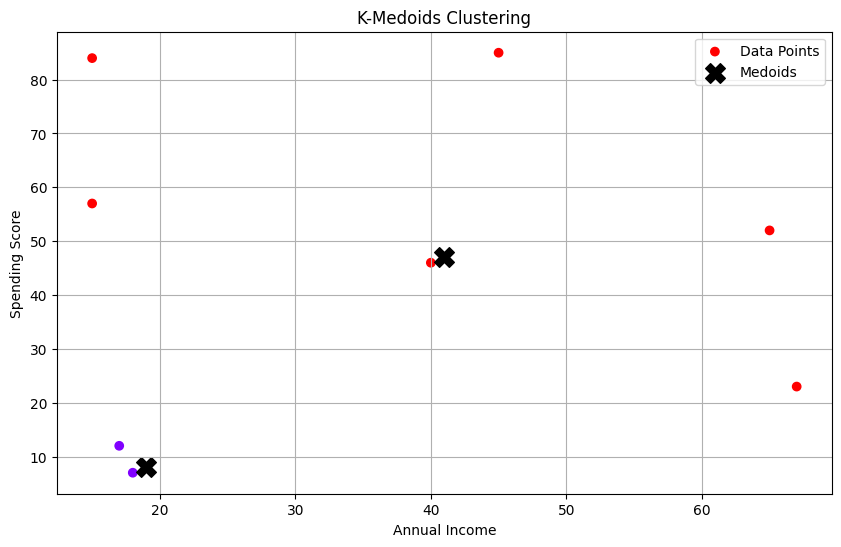

In [5]:
import matplotlib.pyplot as plt
df['Cluster'] = kmedoids.labels_ # Assign cluster labels to DataFrame

plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income'], df['Spending Score'], c=df['Cluster'], cmap='rainbow', label='Data Points')

# Plot medoids
plt.scatter(
    df.iloc[kmedoids.medoid_indices_]['Annual Income'],
    df.iloc[kmedoids.medoid_indices_]['Spending Score'],
    c='black', s=200, marker='X', label='Medoids'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Medoids Clustering')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from google.colab import files
files.upload() # This will prompt the user to upload a file

df_customers = pd.read_csv('/content/Mall_Customers.csv')
display(df_customers.head())

Saving Mall_Customers.csv to Mall_Customers (1).csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Applying K-Medoids to Mall Customer Data

First, we'll select the relevant features (`Annual Income (k$)` and `Spending Score (1-100)`) for clustering. These features are good candidates for segmenting customers based on their spending habits and income.

In [8]:
features = df_customers[['Annual Income (k$)', 'Spending Score (1-100)']]
display(features.head())

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Now, we will apply the K-Medoids algorithm. A common approach is to determine the optimal number of clusters (K) using methods like the Elbow Method or Silhouette Score. For this example, let's start with a reasonable number of clusters, say 5, to see distinct customer segments. We'll use `random_state` for reproducibility.

In [9]:
from sklearn_extra.cluster import KMedoids

kmedoids_mall = KMedoids(n_clusters=5, random_state=42)
kmedoids_mall.fit(features)

df_customers['Cluster'] = kmedoids_mall.labels_

print("Cluster labels:")
print(df_customers['Cluster'].value_counts())
print("\nMedoid indices:")
print(kmedoids_mall.medoid_indices_)

Cluster labels:
Cluster
2    60
1    46
3    39
4    33
0    22
Name: count, dtype: int64

Medoid indices:
[ 25  48  92 161 176]


Finally, let's visualize the results of the K-Medoids clustering. We'll plot the 'Annual Income (k$)' against 'Spending Score (1-100)', coloring each point by its assigned cluster. The medoids will also be marked on the plot.

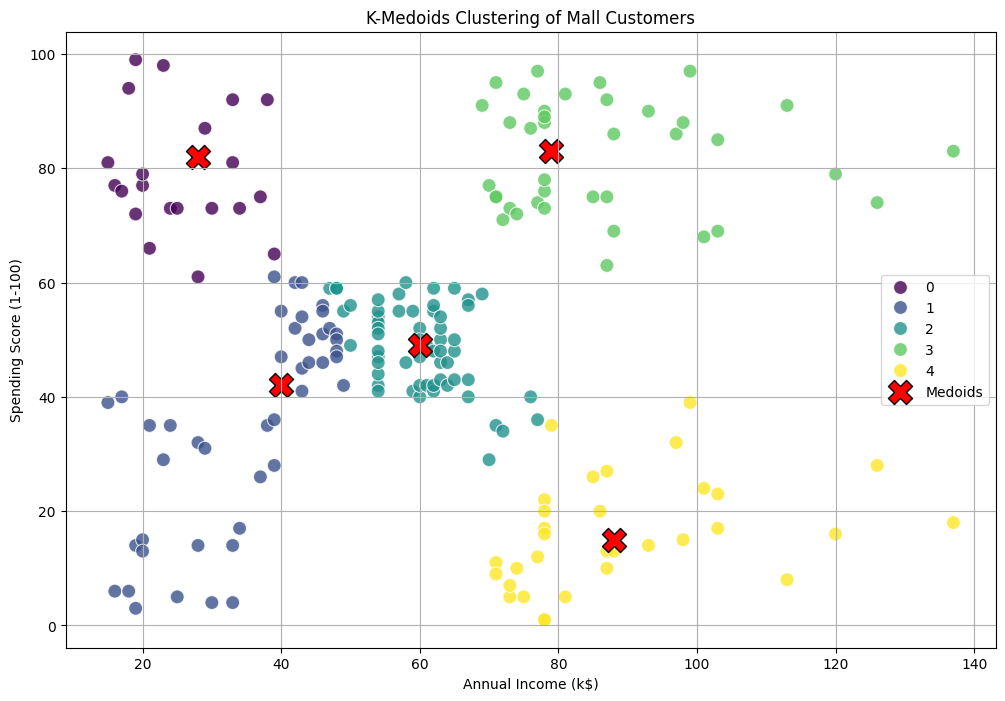

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    data=df_customers,
    legend='full',
    s=100,
    alpha=0.8
)

# Plot medoids
plt.scatter(
    features.iloc[kmedoids_mall.medoid_indices_]['Annual Income (k$)'],
    features.iloc[kmedoids_mall.medoid_indices_]['Spending Score (1-100)'],
    c='red', s=300, marker='X', label='Medoids', edgecolor='black'
)

plt.title('K-Medoids Clustering of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend()
plt.show()

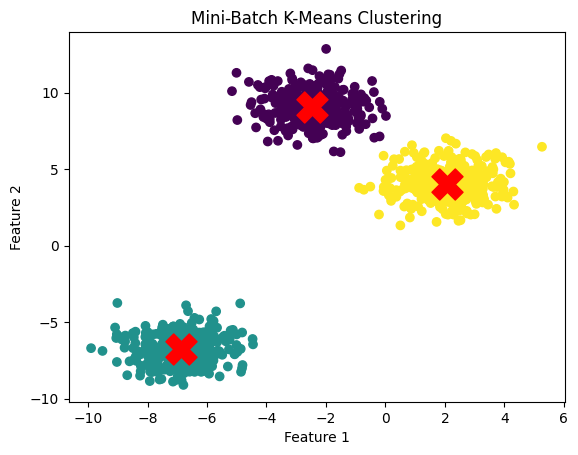

In [18]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
X, _ = make_blobs(n_samples=1000, centers=3, n_features=4, random_state=42)
mbk_means = MiniBatchKMeans(n_clusters=3, batch_size=200, random_state=42)
mbk_means.fit(X)
plt.scatter(X[:, 0], X[:, 1], c=mbk_means.labels_, cmap='viridis')
plt.scatter(mbk_means.cluster_centers_[:, 0], mbk_means.cluster_centers_[:, 1], marker='X', s=500, c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Mini-Batch K-Means Clustering')
plt.show()